<a href="https://colab.research.google.com/github/jskimn/aiservice_lesson2/blob/main/NNBasic/005_minist/minist_TwoLayerNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

minist loader(minist.py)와 dataset을  dataset 디렉토리에 저장
TwoLayerNet.py 파일 다운로드

In [1]:
  import sys, os
  if not os.path.exists("dataset/mnist.py"):
    !wget -P dataset https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/mnist.py

  if not os.path.exists("dataset/train-images-idx3-ubyte.gz"):
    !wget -P dataset https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/train-images-idx3-ubyte.gz

  if not os.path.exists("dataset/train-labels-idx1-ubyte.gz"):
    !wget -P dataset https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/train-labels-idx1-ubyte.gz

  if not os.path.exists("dataset/t10k-images-idx3-ubyte.gz"):
    !wget -P dataset https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/t10k-images-idx3-ubyte.gz

  if not os.path.exists("dataset/t10k-labels-idx1-ubyte.gz"):
    !wget -P dataset https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/t10k-labels-idx1-ubyte.gz

  #common 파일 다운르도
  if not os.path.exists("common/functions.py"):
    !wget -P common https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/common/functions.py

  if not os.path.exists("common/gradient.py"):
    !wget -P common https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/common/gradient.py

  #TwoLayerNet.py 다운로드
  if not os.path.exists("TwoLayerNet.py"):
    !wget https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/TwoLayerNet.py


  #확인
  !realpath dataset/mnist.py
  !ls dataset

--2025-03-23 12:25:56--  https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/mnist.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3655 (3.6K) [text/plain]
Saving to: ‘dataset/mnist.py’

mnist.py            100%[===================>]   3.57K  --.-KB/s    in 0s      

2025-03-23 12:25:57 (40.8 MB/s) - ‘dataset/mnist.py’ saved [3655/3655]

--2025-03-23 12:25:57--  https://raw.githubusercontent.com/jskimn/aiservice_lesson/main/NNBasic/005_minist/dataset/train-images-idx3-ubyte.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, a

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from TwoLayerNet import TwoLayerNet

# 데이터 읽기
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)


# 하이퍼파라미터
iters_num = 10000  # 반복 횟수를 적절히 설정한다.
train_size = x_train.shape[0]
batch_size = 100   # 미니배치 크기
learning_rate = 0.1

#losss 및 정확도 변수
train_loss_list = []
train_acc_list = []
test_acc_list = []

# 1에폭당 반복 수
iter_per_epoch = max(train_size / batch_size, 1)

network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

for i in range(iters_num):
    # 미니배치 획득
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # 기울기 계산
    #grad = network.numerical_gradient(x_batch, t_batch)
    grad = network.gradient(x_batch, t_batch)

    # 매개변수 갱신
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    # 학습 경과 기록
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

    # 1에폭당 정확도 계산
    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))



train acc, test acc | 0.11236666666666667, 0.1135
train acc, test acc | 0.7983833333333333, 0.8009
train acc, test acc | 0.8789333333333333, 0.8832
train acc, test acc | 0.89745, 0.9
train acc, test acc | 0.9076166666666666, 0.9112
train acc, test acc | 0.91455, 0.9174
train acc, test acc | 0.91995, 0.9221
train acc, test acc | 0.9235666666666666, 0.9239
train acc, test acc | 0.9282833333333333, 0.9281
train acc, test acc | 0.9311666666666667, 0.9314
train acc, test acc | 0.9339, 0.9353
train acc, test acc | 0.9362, 0.9367
train acc, test acc | 0.9387, 0.9379
train acc, test acc | 0.9411166666666667, 0.9393
train acc, test acc | 0.9432833333333334, 0.9422
train acc, test acc | 0.94535, 0.9439
train acc, test acc | 0.9466166666666667, 0.9449


Loss 그래프

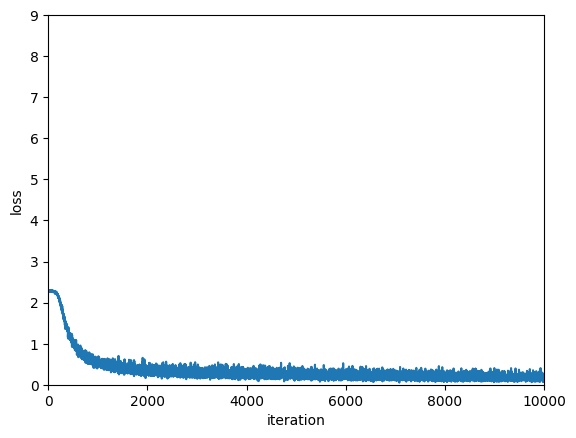

In [5]:
# 그래프 그리기
x = np.arange(len(train_loss_list))
plt.plot(x, train_loss_list)
plt.xlabel("iteration")
plt.ylabel("loss")
plt.ylim(0, 9)
plt.xlim(0, 10000)
plt.show()

정확도 그래프 그리기

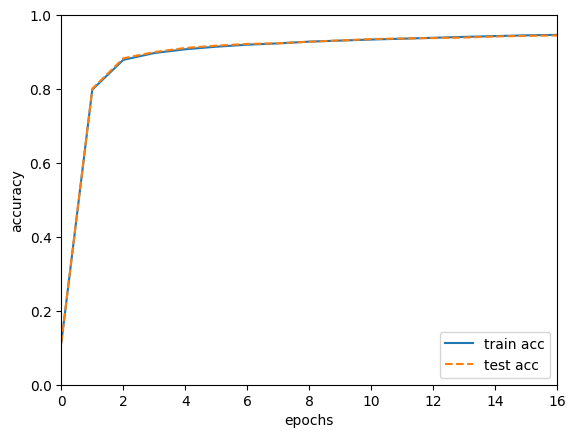

In [6]:
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, label='train acc')
plt.plot(x, test_acc_list, label='test acc', linestyle='--')
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.xlim(0, 16)
plt.legend(loc='lower right')
plt.show()